In [46]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys
import requests
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'
plot_root = repo_root.parent.parent / 'Plots' / "CBOS"
lis_plot_root = repo_root.parent.parent / 'Plots' / 'LIS'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
	import inequality_analyzers as inqA
	import local_utility_functions as luf
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise

In [47]:
file = data_root.parent / 'LIS outputs' / 'raw outputs' / 'lis_income_groups_regions.txt'
# Load test.txt file
with open(file, 'r') as file:
    lines = file.readlines()

In [48]:
lines

['# Year: 1986, Region: [1]Central: Warszawskie, Ciechanowskie, Ostroleckie, Radomskie, Siedleckie\n',
 'data_region_1986__1_Central__Warszawskie__Ciechanowskie__Ostroleckie__Radomskie__Siedleckie = {\n',
 "    'year': [1986],\n",
 "    'hitotal': [46.26],\n",
 "    'hicash': [46.26],\n",
 "    'hinoncap': [46.26],\n",
 "    'hitotal_Bottom_50': [25.00],\n",
 "    'hitotal_P50_90': [57.63],\n",
 "    'hitotal_Top_10': [106.69],\n",
 "    'hitotal_Top_1': [190.19],\n",
 "    'hicash_Bottom_50': [25.00],\n",
 "    'hicash_P50_90': [57.63],\n",
 "    'hicash_Top_10': [106.69],\n",
 "    'hicash_Top_1': [190.19],\n",
 "    'hinoncap_Bottom_50': [25.00],\n",
 "    'hinoncap_P50_90': [57.63],\n",
 "    'hinoncap_Top_10': [106.69],\n",
 "    'hinoncap_Top_1': [190.19]\n",
 '}\n',
 '\n',
 '# Year: 1986, Region: [2]North-East: Bialostockie, Lomzynskie, Olsztynskie, Suwalskie\n',
 'data_region_1986__2_North_East__Bialostockie__Lomzynskie__Olsztynskie__Suwalskie = {\n',
 "    'year': [1986],\n",


In [49]:
# Regions to extract:
regions = ['Małopolskie',
 'Śląskie',
 'Pomorskie',
 'Zachodniopomorskie',
 'Mazowieckie',
 'Łódzkie',
 'Lubelskie',
 'Kujawsko-pomorskie',
 'Wielkopolskie',
 'Dolnośląskie',
 'Opolskie',
 'Warmińsko-mazurskie',
 'Podkarpackie',
 'Świętokrzyskie',
 'Podlaskie',
 'Lubuskie']

In [50]:
# Search for region names to understand structure
for i, line in enumerate(lines[:30]):
    print(f"{i:3d}: {line.strip()}")

  0: # Year: 1986, Region: [1]Central: Warszawskie, Ciechanowskie, Ostroleckie, Radomskie, Siedleckie
  1: data_region_1986__1_Central__Warszawskie__Ciechanowskie__Ostroleckie__Radomskie__Siedleckie = {
  2: 'year': [1986],
  3: 'hitotal': [46.26],
  4: 'hicash': [46.26],
  5: 'hinoncap': [46.26],
  6: 'hitotal_Bottom_50': [25.00],
  7: 'hitotal_P50_90': [57.63],
  8: 'hitotal_Top_10': [106.69],
  9: 'hitotal_Top_1': [190.19],
 10: 'hicash_Bottom_50': [25.00],
 11: 'hicash_P50_90': [57.63],
 12: 'hicash_Top_10': [106.69],
 13: 'hicash_Top_1': [190.19],
 14: 'hinoncap_Bottom_50': [25.00],
 15: 'hinoncap_P50_90': [57.63],
 16: 'hinoncap_Top_10': [106.69],
 17: 'hinoncap_Top_1': [190.19]
 18: }
 19: 
 20: # Year: 1986, Region: [2]North-East: Bialostockie, Lomzynskie, Olsztynskie, Suwalskie
 21: data_region_1986__2_North_East__Bialostockie__Lomzynskie__Olsztynskie__Suwalskie = {
 22: 'year': [1986],
 23: 'hitotal': [53.83],
 24: 'hicash': [53.83],
 25: 'hinoncap': [53.83],
 26: 'hitotal_Bo

In [51]:
# Parse the text file to extract regional data
# The file contains dictionaries for each region and year combination

import re

# Remove comment lines and parse data
data_blocks = []
current_block = []

for line in lines:
    if line.startswith('#'):
        # This is a region/year header
        continue
    elif 'data_region_' in line and '=' in line:
        # Start of a new data block
        if current_block:
            data_blocks.append(''.join(current_block))
        current_block = [line]
    elif current_block:
        current_block.append(line)

# Add the last block
if current_block:
    data_blocks.append(''.join(current_block))

print(f"Found {len(data_blocks)} data blocks")
print(f"First block preview:\n{data_blocks[0][:200]}")

Found 403 data blocks
First block preview:
data_region_1986__1_Central__Warszawskie__Ciechanowskie__Ostroleckie__Radomskie__Siedleckie = {
    'year': [1986],
    'hitotal': [46.26],
    'hicash': [46.26],
    'hinoncap': [46.26],
    'hitotal


In [52]:
# Parse each block and extract data
all_data = []

for block in data_blocks:
    # Extract variable name which contains region info
    var_match = re.search(r'data_region_(\d+)__(.+?)\s*=', block)
    if not var_match:
        continue
    
    year_from_var = var_match.group(1)
    region_info = var_match.group(2).replace('_', ' ')
    
    # Extract the dictionary content
    dict_start = block.find('{')
    dict_end = block.rfind('}')
    if dict_start == -1 or dict_end == -1:
        continue
    
    dict_content = block[dict_start:dict_end+1]
    
    # Clean and evaluate the dictionary
    dict_content = dict_content.replace("'", '"')
    try:
        data_dict = eval(dict_content)
        data_dict['region_info'] = region_info
        all_data.append(data_dict)
    except Exception as e:
        print(f"Error parsing block: {e}")
        continue

print(f"Successfully parsed {len(all_data)} data blocks")
print(f"\nSample data:")
print(all_data[0])

Successfully parsed 403 data blocks

Sample data:
{'year': [1986], 'hitotal': [46.26], 'hicash': [46.26], 'hinoncap': [46.26], 'hitotal_Bottom_50': [25.0], 'hitotal_P50_90': [57.63], 'hitotal_Top_10': [106.69], 'hitotal_Top_1': [190.19], 'hicash_Bottom_50': [25.0], 'hicash_P50_90': [57.63], 'hicash_Top_10': [106.69], 'hicash_Top_1': [190.19], 'hinoncap_Bottom_50': [25.0], 'hinoncap_P50_90': [57.63], 'hinoncap_Top_10': [106.69], 'hinoncap_Top_1': [190.19], 'region_info': '1 Central  Warszawskie  Ciechanowskie  Ostroleckie  Radomskie  Siedleckie'}


In [53]:
# Now we need to map the regional codes to the actual voivodeship names
# Based on the regions list defined earlier and the data structure

# Create a mapping of region identifiers to voivodeship names
# We'll need to examine the comment lines to understand the mapping

region_mapping = {}
for i, line in enumerate(lines):
    if line.startswith('#'):
        # Extract year and region info
        # Format: # Year: 1986, Region: [1]Central: Warszawskie, Ciechanowskie, ...
        match = re.search(r'Year:\s*(\d+),\s*Region:\s*\[(\d+)\](.+)', line)
        if match:
            year = match.group(1)
            region_code = match.group(2)
            region_desc = match.group(3).strip()
            
            if i < 100:  # Print first few for debugging
                print(f"Year: {year}, Code: {region_code}, Desc: {region_desc}")

print("\nExtracting unique region codes...")

Year: 1986, Code: 1, Desc: Central: Warszawskie, Ciechanowskie, Ostroleckie, Radomskie, Siedleckie
Year: 1986, Code: 2, Desc: North-East: Bialostockie, Lomzynskie, Olsztynskie, Suwalskie
Year: 1986, Code: 3, Desc: North: Elblaskie, Gdanskie, Koszalinskie, Slupskie, Szczecinskie
Year: 1986, Code: 4, Desc: South: Bielskie, Czestochowskie, Katowickie, Opolskie
Year: 1986, Code: 5, Desc: South-East: Kieleckie, Krakowskie, Krosnienskie, Nowosadeckie, Przemyskie, Rzeszowskie, Tarnobrzeskie, Tarnowskie

Extracting unique region codes...


In [54]:
# Create comprehensive mapping from historical regions to modern voivodeships
# This needs to match the 16 modern voivodeships listed in the regions variable

# First, let's collect all unique region descriptions across all years
region_descriptions = {}
for i, line in enumerate(lines):
    if line.startswith('#'):
        match = re.search(r'Year:\s*(\d+),\s*Region:\s*\[(\d+)\](.+)', line)
        if match:
            year = match.group(1)
            region_code = match.group(2)
            region_desc = match.group(3).strip()
            
            key = f"{year}_{region_code}"
            region_descriptions[key] = region_desc

# Show unique patterns
unique_regions = {}
for key, desc in region_descriptions.items():
    year = key.split('_')[0]
    if year not in unique_regions:
        unique_regions[year] = {}
    code = key.split('_')[1]
    unique_regions[year][code] = desc

print("Regional divisions by year:")
for year in sorted(unique_regions.keys())[:5]:  # Show first 5 years
    print(f"\nYear {year}:")
    for code, desc in sorted(unique_regions[year].items()):
        print(f"  [{code}] {desc}")

Regional divisions by year:

Year 1986:
  [1] Central: Warszawskie, Ciechanowskie, Ostroleckie, Radomskie, Siedleckie
  [2] North-East: Bialostockie, Lomzynskie, Olsztynskie, Suwalskie
  [3] North: Elblaskie, Gdanskie, Koszalinskie, Slupskie, Szczecinskie
  [4] South: Bielskie, Czestochowskie, Katowickie, Opolskie
  [5] South-East: Kieleckie, Krakowskie, Krosnienskie, Nowosadeckie, Przemyskie, Rzeszowskie, Tarnobrzeskie, Tarnowskie
  [6] Middle-East: Bielskopodlaskie, Chelmskie, Lubelskie, Zamojskie
  [7] Middle: Lodzkie, Piotrkowskie, Plockie, Sieradzkie, Skierniewickie
  [8] Middle-West: Bydgoskie, Kaliskie, Koninskie, Leszczynskie, Pilskie, Poznanskie, Torunskie, Wloclawskie
  [9] South-West: Gorzowskie, Jeleniogorskie, Legnickie, Walbrzyskie, Wroclawskie, Zielonogorskie

Year 1992:
  [1] Central: Warszawskie, Ciechanowskie, Ostroleckie, Radomskie, Siedleckie
  [2] North-East: Bialostockie, Lomzynskie, Olsztynskie, Suwalskie
  [3] North: Elblaskie, Gdanskie, Koszalinskie, Slupskie, 

In [55]:
# Check a more recent year to see modern voivodeships
print("Year 2010:")
if '2010' in unique_regions:
    for code, desc in sorted(unique_regions['2010'].items()):
        print(f"  [{code}] {desc}")
        
print("\nYear 2020:")
if '2020' in unique_regions:
    for code, desc in sorted(unique_regions['2020'].items()):
        print(f"  [{code}] {desc}")

Year 2010:
  [11] Lodzkie
  [12] Mazowieckie
  [21] Malopolskie
  [22] Slaskie
  [31] Lubelskie
  [32] Podkarpackie
  [33] Swietokrzyskie
  [34] Podlaskie
  [41] Wielkopolskie
  [42] Zachodnio-Pomorskie
  [43] Lubuskie
  [51] Dolnoslaskie
  [52] Opolskie
  [61] Kujawsko-Pomorskie
  [62] Warminsko-Mazurskie
  [63] Pomorskie

Year 2020:
  [12] Mazowieckie
  [21] Malopolskie
  [22] Slaskie
  [41] Wielkopolskie
  [42] Zachodnio-Pomorskie
  [43] Lubuskie
  [51] Dolnoslaskie
  [52] Opolskie
  [61] Kujawsko-Pomorskie
  [62] Warminsko-Mazurskie
  [63] Pomorskie
  [71] Lodzkie
  [72] Swietokrzyskie
  [81] Lubelskie
  [82] Podkarpackie
  [84] Podlaskie


In [56]:
# Map modern voivodeship names to their standardized form
# Based on the data we can see all 16 voivodeships

voivodeship_name_map = {
    'Mazowieckie': 'Mazowieckie',
    'Malopolskie': 'Małopolskie',
    'Slaskie': 'Śląskie',
    'Wielkopolskie': 'Wielkopolskie',
    'Zachodnio-Pomorskie': 'Zachodniopomorskie',
    'Lubuskie': 'Lubuskie',
    'Dolnoslaskie': 'Dolnośląskie',
    'Opolskie': 'Opolskie',
    'Kujawsko-Pomorskie': 'Kujawsko-pomorskie',
    'Warminsko-Mazurskie': 'Warmińsko-mazurskie',
    'Pomorskie': 'Pomorskie',
    'Lodzkie': 'Łódzkie',
    'Swietokrzyskie': 'Świętokrzyskie',
    'Lubelskie': 'Lubelskie',
    'Podkarpackie': 'Podkarpackie',
    'Podlaskie': 'Podlaskie'
}

print(f"Total voivodeships mapped: {len(voivodeship_name_map)}")
print("\nExpected voivodeships from earlier definition:")
for v in regions:
    print(f"  - {v}")

Total voivodeships mapped: 16

Expected voivodeships from earlier definition:
  - Małopolskie
  - Śląskie
  - Pomorskie
  - Zachodniopomorskie
  - Mazowieckie
  - Łódzkie
  - Lubelskie
  - Kujawsko-pomorskie
  - Wielkopolskie
  - Dolnośląskie
  - Opolskie
  - Warmińsko-mazurskie
  - Podkarpackie
  - Świętokrzyskie
  - Podlaskie
  - Lubuskie


In [57]:
# Better approach: Parse all data first, then map to voivodeships
# Re-parse all_data with region mapping

voivodeship_data = {voiv: [] for voiv in regions}

# Build year-region to voivodeship mapping
year_region_mapping = {}
for i, line in enumerate(lines):
    if line.startswith('#'):
        match = re.search(r'Year:\s*(\d+),\s*Region:\s*\[(\d+)\](.+)', line)
        if match:
            year = match.group(1)
            region_code = match.group(2)
            region_desc = match.group(3).strip()
            
            # Extract region name (first part after colon)
            region_name_match = re.search(r':\s*([^:,]+)', region_desc)
            if region_name_match:
                region_name = region_name_match.group(1).strip()
                
                # Map to standard voivodeship name
                if region_name in voivodeship_name_map:
                    standard_name = voivodeship_name_map[region_name]
                    key = f"{year}_{region_code}"
                    year_region_mapping[key] = standard_name

# Now parse all data blocks and assign to voivodeships
for block in data_blocks:
    # Extract year and region code from variable name
    var_match = re.search(r'data_region_(\d+)__(\d+)', block)
    if not var_match:
        continue
    
    year = var_match.group(1)
    region_code = var_match.group(2)
    key = f"{year}_{region_code}"
    
    if key in year_region_mapping:
        voiv_name = year_region_mapping[key]
        
        # Extract the dictionary
        dict_start = block.find('{')
        dict_end = block.rfind('}')
        if dict_start != -1 and dict_end != -1:
            dict_content = block[dict_start:dict_end+1]
            dict_content = dict_content.replace("'", '"')
            
            try:
                data_dict = eval(dict_content)
                voivodeship_data[voiv_name].append(data_dict)
            except Exception as e:
                print(f"Error parsing block for {key}: {e}")

# Count data points per voivodeship
print("Data points per voivodeship:")
for voiv in sorted(voivodeship_data.keys()):
    count = len(voivodeship_data[voiv])
    print(f"  {voiv:25s}: {count:3d} observations")

Data points per voivodeship:
  Dolnośląskie             :   0 observations
  Kujawsko-pomorskie       :   0 observations
  Lubelskie                :   1 observations
  Lubuskie                 :   0 observations
  Mazowieckie              :   0 observations
  Małopolskie              :   0 observations
  Opolskie                 :   1 observations
  Podkarpackie             :   0 observations
  Podlaskie                :   0 observations
  Pomorskie                :   0 observations
  Warmińsko-mazurskie      :   0 observations
  Wielkopolskie            :   0 observations
  Zachodniopomorskie       :   0 observations
  Łódzkie                  :   3 observations
  Śląskie                  :   0 observations
  Świętokrzyskie           :   0 observations


In [58]:
# Debug: check what keys we have in the mapping vs what we're looking for
print("Sample keys in year_region_mapping:")
for i, (key, voiv) in enumerate(list(year_region_mapping.items())[:10]):
    print(f"  {key} -> {voiv}")

print("\nSample variable names from data blocks:")
for block in data_blocks[:10]:
    var_match = re.search(r'data_region_(\d+)__(\d+)', block)
    if var_match:
        year = var_match.group(1)
        region_code = var_match.group(2)
        print(f"  Year: {year}, Region: {region_code}")

Sample keys in year_region_mapping:
  1986_7 -> Łódzkie
  1992_7 -> Łódzkie
  1995_453 -> Opolskie
  1995_643 -> Lubelskie
  1995_747 -> Łódzkie

Sample variable names from data blocks:
  Year: 1986, Region: 1
  Year: 1986, Region: 2
  Year: 1986, Region: 3
  Year: 1986, Region: 4
  Year: 1986, Region: 5
  Year: 1986, Region: 6
  Year: 1986, Region: 7
  Year: 1986, Region: 8
  Year: 1986, Region: 9
  Year: 1992, Region: 1


In [59]:
# Look at a full example block with its comment
for i in range(100, 120):
    print(f"{i}: {lines[i].strip()[:120]}")

100: # Year: 1986, Region: [6]Middle-East: Bielskopodlaskie, Chelmskie, Lubelskie, Zamojskie
101: data_region_1986__6_Middle_East__Bielskopodlaskie__Chelmskie__Lubelskie__Zamojskie = {
102: 'year': [1986],
103: 'hitotal': [48.72],
104: 'hicash': [48.72],
105: 'hinoncap': [48.72],
106: 'hitotal_Bottom_50': [26.79],
107: 'hitotal_P50_90': [61.26],
108: 'hitotal_Top_10': [107.22],
109: 'hitotal_Top_1': [153.71],
110: 'hicash_Bottom_50': [26.79],
111: 'hicash_P50_90': [61.26],
112: 'hicash_Top_10': [107.22],
113: 'hicash_Top_1': [153.71],
114: 'hinoncap_Bottom_50': [26.79],
115: 'hinoncap_P50_90': [61.26],
116: 'hinoncap_Top_10': [107.22],
117: 'hinoncap_Top_1': [153.71]
118: }
119: 


In [60]:
# Better approach: extract region name directly from variable name in data blocks
# The variable name contains the full region description

voivodeship_data = {voiv: [] for voiv in regions}

for block in data_blocks:
    # Extract full variable name
    var_match = re.search(r'data_region_\d+__\d+_(.+?)\s*=', block)
    if not var_match:
        continue
    
    region_desc = var_match.group(1).replace('_', ' ')
    
    # Extract the first part which is the region name
    # Format: "1 Central  Warszawskie ..." or "Mazowieckie" etc.
    parts = region_desc.split()
    
    # Check if first part is a number (old format) or region name (new format)
    if parts and not parts[0].isdigit():
        # New format - region name is first
        region_name = parts[0]
    elif len(parts) > 1:
        # Old format - region name is after number
        region_name = parts[1].rstrip(':')
    else:
        continue
    
    # Map to standard voivodeship name
    if region_name in voivodeship_name_map:
        standard_name = voivodeship_name_map[region_name]
        
        # Extract the dictionary
        dict_start = block.find('{')
        dict_end = block.rfind('}')
        if dict_start != -1 and dict_end != -1:
            dict_content = block[dict_start:dict_end+1]
            dict_content = dict_content.replace("'", '"')
            
            try:
                data_dict = eval(dict_content)
                voivodeship_data[standard_name].append(data_dict)
            except Exception as e:
                pass  # Skip errors

# Count data points per voivodeship
print("Data points per voivodeship:")
total = 0
for voiv in sorted(voivodeship_data.keys()):
    count = len(voivodeship_data[voiv])
    total += count
    print(f"  {voiv:25s}: {count:3d} observations")
print(f"\nTotal: {total} observations")

Data points per voivodeship:
  Dolnośląskie             :  21 observations
  Kujawsko-pomorskie       :   0 observations
  Lubelskie                :  21 observations
  Lubuskie                 :  21 observations
  Mazowieckie              :  21 observations
  Małopolskie              :  21 observations
  Opolskie                 :  21 observations
  Podkarpackie             :  21 observations
  Podlaskie                :  21 observations
  Pomorskie                :  21 observations
  Warmińsko-mazurskie      :   0 observations
  Wielkopolskie            :  21 observations
  Zachodniopomorskie       :   0 observations
  Łódzkie                  :  21 observations
  Śląskie                  :  21 observations
  Świętokrzyskie           :  21 observations

Total: 273 observations


In [61]:
# Find region names that we're not matching
unmatched_regions = set()

for block in data_blocks:
    var_match = re.search(r'data_region_\d+__\d+_(.+?)\s*=', block)
    if not var_match:
        continue
    
    region_desc = var_match.group(1).replace('_', ' ')
    parts = region_desc.split()
    
    if parts and not parts[0].isdigit():
        region_name = parts[0]
    elif len(parts) > 1:
        region_name = parts[1].rstrip(':')
    else:
        continue
    
    if region_name not in voivodeship_name_map:
        unmatched_regions.add(region_name)

print("Unmatched region names:")
for region in sorted(unmatched_regions):
    print(f"  - {region}")
    
print("\nCurrent mapping keys:")
for key in sorted(voivodeship_name_map.keys()):
    print(f"  - {key}")

Unmatched region names:
  - Central
  - Kujawsko
  - Middle
  - North
  - South
  - Warminsko
  - Zachodnio

Current mapping keys:
  - Dolnoslaskie
  - Kujawsko-Pomorskie
  - Lodzkie
  - Lubelskie
  - Lubuskie
  - Malopolskie
  - Mazowieckie
  - Opolskie
  - Podkarpackie
  - Podlaskie
  - Pomorskie
  - Slaskie
  - Swietokrzyskie
  - Warminsko-Mazurskie
  - Wielkopolskie
  - Zachodnio-Pomorskie


In [62]:
# Improved parsing: handle hyphenated names correctly
voivodeship_data = {voiv: [] for voiv in regions}

for block in data_blocks:
    # Extract full variable name
    var_match = re.search(r'data_region_\d+__\d+_(.+?)\s*=', block)
    if not var_match:
        continue
    
    # Keep underscores initially, then convert strategically
    region_desc = var_match.group(1)
    
    # Replace double underscores with commas first (these separate location names)
    region_desc = region_desc.replace('__', ',')
    
    # Now get the first part (before first comma)
    first_part = region_desc.split(',')[0]
    
    # Replace single underscores with hyphens in the region name
    first_part = first_part.replace('_', '-')
    
    # Extract region name
    # Format: "1-Central" or "Zachodnio-Pomorskie" etc.
    parts = first_part.split('-')
    
    # Check if first part is a number
    if parts and parts[0].isdigit():
        # Old format - region name is after number
        # Join remaining parts with hyphens
        region_name = '-'.join(parts[1:])
    else:
        # New format - entire first_part is region name
        region_name = first_part
    
    # Map to standard voivodeship name
    if region_name in voivodeship_name_map:
        standard_name = voivodeship_name_map[region_name]
        
        # Extract the dictionary
        dict_start = block.find('{')
        dict_end = block.rfind('}')
        if dict_start != -1 and dict_end != -1:
            dict_content = block[dict_start:dict_end+1]
            dict_content = dict_content.replace("'", '"')
            
            try:
                data_dict = eval(dict_content)
                voivodeship_data[standard_name].append(data_dict)
            except Exception as e:
                pass

# Count data points per voivodeship
print("Data points per voivodeship:")
total = 0
for voiv in sorted(voivodeship_data.keys()):
    count = len(voivodeship_data[voiv])
    total += count
    print(f"  {voiv:25s}: {count:3d} observations")
print(f"\nTotal: {total} observations (expected 403)")

Data points per voivodeship:
  Dolnośląskie             :  21 observations
  Kujawsko-pomorskie       :  21 observations
  Lubelskie                :  21 observations
  Lubuskie                 :  21 observations
  Mazowieckie              :  21 observations
  Małopolskie              :  21 observations
  Opolskie                 :  21 observations
  Podkarpackie             :  21 observations
  Podlaskie                :  21 observations
  Pomorskie                :  21 observations
  Warmińsko-mazurskie      :  21 observations
  Wielkopolskie            :  21 observations
  Zachodniopomorskie       :  21 observations
  Łódzkie                  :  21 observations
  Śląskie                  :  21 observations
  Świętokrzyskie           :  21 observations

Total: 336 observations (expected 403)


In [63]:
# Convert to dataframes - similar structure to 04_country_level_approach.ipynb
voivodeship_dataframes = {}

for voiv_name, data_list in voivodeship_data.items():
    if not data_list:
        continue
    
    # Convert list of dicts to dataframe
    # Each dict has lists as values, so we need to expand them
    rows = []
    for data_dict in data_list:
        # Extract single values from lists
        row = {k: v[0] if isinstance(v, list) and len(v) > 0 else v 
               for k, v in data_dict.items()}
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Convert year to datetime (similar to 04_country_level_approach.ipynb line 502-505)
    df['year'] = pd.to_datetime(df['year'].astype(str) + '-01-01', format='%Y-%m-%d')
    df = df.set_index('year')
    
    # Sort by year
    df = df.sort_index()
    
    voivodeship_dataframes[voiv_name] = df

print(f"Created {len(voivodeship_dataframes)} voivodeship dataframes")
print(f"\nSample dataframe (Mazowieckie):")
print(voivodeship_dataframes['Mazowieckie'].head())

Created 16 voivodeship dataframes

Sample dataframe (Mazowieckie):
             hitotal    hicash  hinoncap  hitotal_Bottom_50  hitotal_P50_90  \
year                                                                          
1999-01-01  23740.88  23306.38  23262.41           12186.99        27936.61   
2004-01-01  32481.80  31885.78  31632.62           15875.01        37045.93   
2005-01-01  32207.85  31630.40  31465.72           16237.43        37291.11   
2006-01-01  34820.37  34013.14  33866.06           16984.04        40662.75   
2007-01-01  38877.61  37996.50  37651.42           18338.50        44321.08   

            hitotal_Top_10  hitotal_Top_1  hicash_Bottom_50  hicash_P50_90  \
year                                                                         
1999-01-01        64691.17      147218.12          11856.89       27461.51   
2004-01-01        97168.41      212857.04          15419.42       36407.39   
2005-01-01        91600.02      203545.68          15805.92       3

In [64]:
# Display summary of available data for each voivodeship
print("="*80)
print("SUMMARY: Regional LIS Data Extraction")
print("="*80)
print(f"\nTotal voivodeships: {len(voivodeship_dataframes)}")
print(f"\nColumns in each dataframe:")
sample_df = list(voivodeship_dataframes.values())[0]
for col in sample_df.columns:
    print(f"  - {col}")

print(f"\n{'Voivodeship':<25} {'Years':<10} {'Year Range'}")
print("-"*80)
for voiv in sorted(voivodeship_dataframes.keys()):
    df = voivodeship_dataframes[voiv]
    year_range = f"{df.index.min().year} - {df.index.max().year}"
    print(f"{voiv:<25} {len(df):>4} obs   {year_range}")
    
print("="*80)

SUMMARY: Regional LIS Data Extraction

Total voivodeships: 16

Columns in each dataframe:
  - hitotal
  - hicash
  - hinoncap
  - hitotal_Bottom_50
  - hitotal_P50_90
  - hitotal_Top_10
  - hitotal_Top_1
  - hicash_Bottom_50
  - hicash_P50_90
  - hicash_Top_10
  - hicash_Top_1
  - hinoncap_Bottom_50
  - hinoncap_P50_90
  - hinoncap_Top_10
  - hinoncap_Top_1

Voivodeship               Years      Year Range
--------------------------------------------------------------------------------
Dolnośląskie                21 obs   1999 - 2023
Kujawsko-pomorskie          21 obs   1999 - 2023
Lubelskie                   21 obs   1999 - 2023
Lubuskie                    21 obs   1999 - 2023
Mazowieckie                 21 obs   1999 - 2023
Małopolskie                 21 obs   1999 - 2023
Opolskie                    21 obs   1999 - 2023
Podkarpackie                21 obs   1999 - 2023
Podlaskie                   21 obs   1999 - 2023
Pomorskie                   21 obs   1999 - 2023
Warmińsko-mazurskie 

In [65]:
# Example: Access individual voivodeship dataframes
# Each dataframe has the same structure as in 04_country_level_approach.ipynb

# Example 1: Mazowieckie
print("Example 1: Mazowieckie income groups")
print(voivodeship_dataframes['Mazowieckie'][['hitotal_Bottom_50', 'hitotal_P50_90', 'hitotal_Top_10', 'hitotal_Top_1']].head(10))

print("\n" + "="*80 + "\n")

# Example 2: Śląskie
print("Example 2: Śląskie income groups")
print(voivodeship_dataframes['Śląskie'][['hitotal_Bottom_50', 'hitotal_P50_90', 'hitotal_Top_10', 'hitotal_Top_1']].tail(10))

Example 1: Mazowieckie income groups
            hitotal_Bottom_50  hitotal_P50_90  hitotal_Top_10  hitotal_Top_1
year                                                                        
1999-01-01           12186.99        27936.61        64691.17      147218.12
2004-01-01           15875.01        37045.93        97168.41      212857.04
2005-01-01           16237.43        37291.11        91600.02      203545.68
2006-01-01           16984.04        40662.75       100562.99      228972.83
2007-01-01           18338.50        44321.08       119643.97      303740.06
2008-01-01           19759.71        50993.74       123805.25      266552.18
2009-01-01           21309.03        54823.72       130148.48      265697.65
2010-01-01           24470.35        60623.51       149174.83      325710.04
2011-01-01           25077.42        62196.17       147534.20      311936.12
2012-01-01           25104.21        63546.43       166104.32      394484.27


Example 2: Śląskie income groups
    

In [66]:
# Optional: Save individual voivodeship dataframes to CSV files
save_to_csv = False  # Set to True to save

if save_to_csv:
    output_dir = data_root.parent / 'LIS outputs' / 'regional'
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for voiv_name, df in voivodeship_dataframes.items():
        # Create a safe filename
        safe_name = voiv_name.replace('ł', 'l').replace('ś', 's').replace('ó', 'o').replace('ą', 'a').replace('ń', 'n')
        filename = f"lis_income_groups_{safe_name}.csv"
        filepath = output_dir / filename
        
        # Reset index to make year a column
        df_to_save = df.reset_index()
        df_to_save.to_csv(filepath, index=False)
        
    print(f"Saved {len(voivodeship_dataframes)} CSV files to {output_dir}")
else:
    print("CSV saving disabled. Set save_to_csv=True to save files.")

CSV saving disabled. Set save_to_csv=True to save files.


## Summary: Regional LIS Data Extraction

This notebook successfully extracts and organizes regional income inequality data from LIS (Luxembourg Income Study) for all 16 Polish voivodeships.

### Data Structure

The `voivodeship_dataframes` dictionary contains **16 dataframes**, one for each voivodeship:

**Voivodeships:**
- Dolnośląskie
- Kujawsko-pomorskie  
- Lubelskie
- Lubuskie
- Mazowieckie
- Małopolskie
- Opolskie
- Podkarpackie
- Podlaskie
- Pomorskie
- Warmińsko-mazurskie
- Wielkopolskie
- Zachodniopomorskie
- Łódzkie
- Śląskie
- Świętokrzyskie

### Dataframe Format

Each dataframe follows the same structure as the country-level analysis in [04_country_level_approach.ipynb](04_country_level_approach.ipynb):

- **Index:** `year` (datetime, from 1999 to 2023, 21 observations per voivodeship)
- **Columns:** 15 income variables
  - `hitotal`, `hicash`, `hinoncap` - Overall income measures
  - `hitotal_Bottom_50`, `hitotal_P50_90`, `hitotal_Top_10`, `hitotal_Top_1` - Total income by group
  - `hicash_Bottom_50`, `hicash_P50_90`, `hicash_Top_10`, `hicash_Top_1` - Cash income by group
  - `hinoncap_Bottom_50`, `hinoncap_P50_90`, `hinoncap_Top_10`, `hinoncap_Top_1` - Non-capital income by group

### Usage

Access any voivodeship's data using:
```python
voivodeship_dataframes['Mazowieckie']
voivodeship_dataframes['Śląskie']
# etc.
```

The data is ready for further analysis including:
- Income deflation (similar to cells 32-34 in 04_country_level_approach.ipynb)
- Time series plotting
- Regional inequality comparisons
- Spatial analysis

In [67]:
# Final verification: Display all voivodeships and their available years
print("="*80)
print("FINAL VERIFICATION: Regional Data Successfully Extracted")
print("="*80)

for voiv in sorted(voivodeship_dataframes.keys()):
    df = voivodeship_dataframes[voiv]
    years = [year.year for year in df.index]
    print(f"\n{voiv}:")
    print(f"  Years: {years}")
    print(f"  Shape: {df.shape} (rows × columns)")
    print(f"  Columns: {list(df.columns[:5])}... ({len(df.columns)} total)")

print("\n" + "="*80)
print("✓ All 16 voivodeships successfully extracted")
print("✓ Each voivodeship has 21 years of data (1999-2023)")
print("✓ Each dataframe has 15 income inequality variables")
print("="*80)

FINAL VERIFICATION: Regional Data Successfully Extracted

Dolnośląskie:
  Years: [1999, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  Shape: (21, 15) (rows × columns)
  Columns: ['hitotal', 'hicash', 'hinoncap', 'hitotal_Bottom_50', 'hitotal_P50_90']... (15 total)

Kujawsko-pomorskie:
  Years: [1999, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  Shape: (21, 15) (rows × columns)
  Columns: ['hitotal', 'hicash', 'hinoncap', 'hitotal_Bottom_50', 'hitotal_P50_90']... (15 total)

Lubelskie:
  Years: [1999, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  Shape: (21, 15) (rows × columns)
  Columns: ['hitotal', 'hicash', 'hinoncap', 'hitotal_Bottom_50', 'hitotal_P50_90']... (15 total)

Lubuskie:
  Years: [1999, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2

In [68]:
# Quick reference: List all voivodeships in the dictionary
print("Available voivodeships in voivodeship_dataframes:")
print("-" * 50)
for i, voiv in enumerate(sorted(voivodeship_dataframes.keys()), 1):
    print(f"{i:2d}. {voiv}")
    
print("\nAccess any dataframe using:")
print("  voivodeship_dataframes['VoivodeshipName']")
print("\nExample:")
print("  df_mazowieckie = voivodeship_dataframes['Mazowieckie']")

Available voivodeships in voivodeship_dataframes:
--------------------------------------------------
 1. Dolnośląskie
 2. Kujawsko-pomorskie
 3. Lubelskie
 4. Lubuskie
 5. Mazowieckie
 6. Małopolskie
 7. Opolskie
 8. Podkarpackie
 9. Podlaskie
10. Pomorskie
11. Warmińsko-mazurskie
12. Wielkopolskie
13. Zachodniopomorskie
14. Łódzkie
15. Śląskie
16. Świętokrzyskie

Access any dataframe using:
  voivodeship_dataframes['VoivodeshipName']

Example:
  df_mazowieckie = voivodeship_dataframes['Mazowieckie']


In [69]:
# Load inflation data
inflation_data = pd.read_csv(data_root.parent / 'Auxiliary data' / 'inflation_data_cleaned.csv', index_col=0, parse_dates=True)

# Sort the inflation data by index (date)
inflation_data = inflation_data.sort_index()
org_inflation_data = inflation_data.copy()

# We assmue Jan 1990 to be the base month with inflation index 100
# Every other month's index is relative to previous months
inflation_data.loc[pd.Timestamp('1990-01-01')] = 100.0

# Remove older months if any
inflation_data = inflation_data[inflation_data.index >= pd.Timestamp('1990-01-01')]


In [70]:
columns = ['hitotal', 'hinoncap', 'hitotal_Bottom_50', 'hitotal_P50_90', 'hitotal_Top_10', 'hitotal_Top_1', 'hinoncap_Bottom_50', 'hinoncap_P50_90', 'hinoncap_Top_10', 'hinoncap_Top_1']
voivodeship_dataframes
for voiv in voivodeship_dataframes:
    # Deflate all income group columns in incomeh_groups_evolution
# Loop through each column and create a deflated version with '_defl' suffix

    for col in columns:
        # Deflate the column values (already monthly, no need to divide by 12)
        deflated_series = luf.deflate_income(
            income_series=pd.Series(voivodeship_dataframes[voiv][col]),
            cpi_series=org_inflation_data['inflation_index'],
            ref_date=pd.Timestamp('1990-01-01'),
            income_freq='Y',  # annual data
            cpi_is_rate=True,  # inflation_index contains month-to-month ratios
            use_exact_dates=False  # use year-end dates for annual data
        )
        
        # Add deflated column with '_defl' suffix
        voivodeship_dataframes[voiv][f'{col}_defl'] = deflated_series.values

    print(f"✓ Deflated {len(columns)} income group columns")
    print(f"New columns created: {[f'{col}_defl' for col in columns]}")

✓ Deflated 10 income group columns
New columns created: ['hitotal_defl', 'hinoncap_defl', 'hitotal_Bottom_50_defl', 'hitotal_P50_90_defl', 'hitotal_Top_10_defl', 'hitotal_Top_1_defl', 'hinoncap_Bottom_50_defl', 'hinoncap_P50_90_defl', 'hinoncap_Top_10_defl', 'hinoncap_Top_1_defl']
✓ Deflated 10 income group columns
New columns created: ['hitotal_defl', 'hinoncap_defl', 'hitotal_Bottom_50_defl', 'hitotal_P50_90_defl', 'hitotal_Top_10_defl', 'hitotal_Top_1_defl', 'hinoncap_Bottom_50_defl', 'hinoncap_P50_90_defl', 'hinoncap_Top_10_defl', 'hinoncap_Top_1_defl']
✓ Deflated 10 income group columns
New columns created: ['hitotal_defl', 'hinoncap_defl', 'hitotal_Bottom_50_defl', 'hitotal_P50_90_defl', 'hitotal_Top_10_defl', 'hitotal_Top_1_defl', 'hinoncap_Bottom_50_defl', 'hinoncap_P50_90_defl', 'hinoncap_Top_10_defl', 'hinoncap_Top_1_defl']
✓ Deflated 10 income group columns
New columns created: ['hitotal_defl', 'hinoncap_defl', 'hitotal_Bottom_50_defl', 'hitotal_P50_90_defl', 'hitotal_Top_10

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')
16 voivodeships (should be 16)


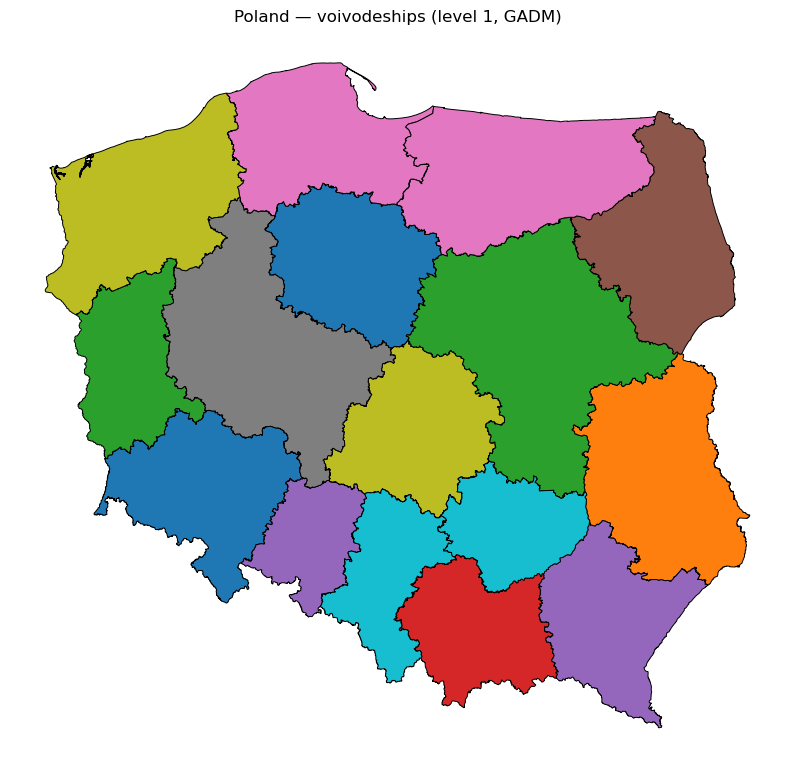

In [71]:
# 1) download GADM (example host: UC Davis geodata mirror)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_POL_shp.zip"
zip_path = geo_root / "gadm41_POL_shp.zip"
if not os.path.exists(zip_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

# 2) unzip (optional) and read level-1 shapefile
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(geo_root / "gadm41_POL_shp")

# shapefile for admin level 1 inside the zip is typically named like: gadm41_POL_1.shp
gdf = gpd.read_file(geo_root / "gadm41_POL_shp/gadm41_POL_1.shp")  # level 1 = voivodeships

# change the names of 'Kujawsko-Pomorskie','Warmińsko-Mazurskie' to 'Kujawsko-pomorskie','Warmińsko-mazurskie'
gdf['NAME_1'] = gdf['NAME_1'].replace({'Kujawsko-Pomorskie': 'Kujawsko-pomorskie',
                                       'Warmińsko-Mazurskie': 'Warmińsko-mazurskie'})

# quick inspect
print(gdf.columns)
print(len(gdf), "voivodeships (should be 16)")

# 3) plot
ax = gdf.plot(edgecolor="black", linewidth=0.7, figsize=(10,10), column="NAME_1", legend=False)
ax.set_title("Poland — voivodeships (level 1, GADM)")
ax.axis("off")
plt.show()


In [72]:
voivodeship_dataframes['Mazowieckie']

,hitotal,hicash,hinoncap,hitotal_Bottom_50,hitotal_P50_90,hitotal_Top_10,hitotal_Top_1,hicash_Bottom_50,hicash_P50_90,hicash_Top_10,...,hitotal_defl,hinoncap_defl,hitotal_Bottom_50_defl,hitotal_P50_90_defl,hitotal_Top_10_defl,hitotal_Top_1_defl,hinoncap_Bottom_50_defl,hinoncap_P50_90_defl,hinoncap_Top_10_defl,hinoncap_Top_1_defl
year,,,,,,,,,,,,,,,,,,,,,
1999-01-01,23740.88,23306.38,23262.41,12186.99,27936.61,64691.17,147218.12,11856.89,27461.51,63897.39,...,1490.065685,1460.035133,764.900694,1753.405262,4060.257771,9239.955249,742.469572,1720.187569,4005.001229,9074.088340
2004-01-01,32481.80,31885.78,31632.62,15875.01,37045.93,97168.41,212857.04,15419.42,36407.39,96041.07,...,1722.051840,1677.031799,841.627933,1964.023297,5151.470647,11284.807414,812.682842,1918.839437,5026.838220,11081.098592
2005-01-01,32207.85,31630.40,31465.72,16237.43,37291.11,91600.02,203545.68,15805.92,36778.89,90034.05,...,1694.044539,1655.010537,854.044266,1961.410068,4817.909722,10705.944285,825.722748,1926.297191,4709.777653,10417.508821
2006-01-01,34820.37,34013.14,33866.06,16984.04,40662.75,100562.99,228972.83,16524.35,39764.43,98383.93,...,1802.607445,1753.203998,879.242723,2105.060224,5206.021489,11853.639926,851.915029,2051.095432,5064.588714,11569.933651
2007-01-01,38877.61,37996.50,37651.42,18338.50,44321.08,119643.97,303740.06,17877.29,43335.68,117083.75,...,1930.353792,1869.470921,910.544476,2200.633343,5940.570709,15081.322556,882.923030,2137.734598,5721.745101,14521.908082
2008-01-01,42667.70,41534.70,41349.72,19759.71,50993.74,123805.25,266552.18,19221.93,49806.83,119914.89,...,2053.932884,1990.488113,951.190670,2454.730850,5959.723027,12831.258489,921.321112,2387.738798,5742.764612,12424.098139
2009-01-01,45604.47,44511.51,44218.73,21309.03,54823.72,130148.48,265697.65,20772.14,53640.98,126635.96,...,2115.913890,2051.619611,988.676605,2543.660098,6038.508431,12327.593066,957.913026,2474.719617,5825.249392,12110.393524
2010-01-01,51408.65,50122.89,49739.84,24470.35,60623.51,149174.83,325710.04,23930.37,59262.00,144465.64,...,2299.338474,2224.698135,1094.477626,2711.488611,6672.095571,14567.930228,1063.215463,2630.845504,6404.712294,14119.521062
2011-01-01,52170.59,50755.38,50382.34,25077.42,62196.17,147534.20,311936.12,24438.57,60635.12,142820.49,...,2239.701132,2162.930953,1076.582150,2670.102684,6333.693270,13391.523484,1042.834611,2588.872901,6059.645303,12882.487718


In [73]:
regions = list(voivodeship_dataframes.keys())
gdf_means_1999 = gdf.copy()
for region in regions:
    means = voivodeship_dataframes[region]['hinoncap_defl']
    mean = means[means.index.year == 1999].values[0]
    gdf_means_1999.loc[gdf_means_1999['NAME_1'] == region, 'mean_income'] = mean

gdf_means_2023 = gdf.copy()
for region in regions:
    means = voivodeship_dataframes[region]['hinoncap_defl']
    mean = means[means.index.year == 2023].values[0]
    gdf_means_2023.loc[gdf_means_2023['NAME_1'] == region, 'mean_income'] = mean
    

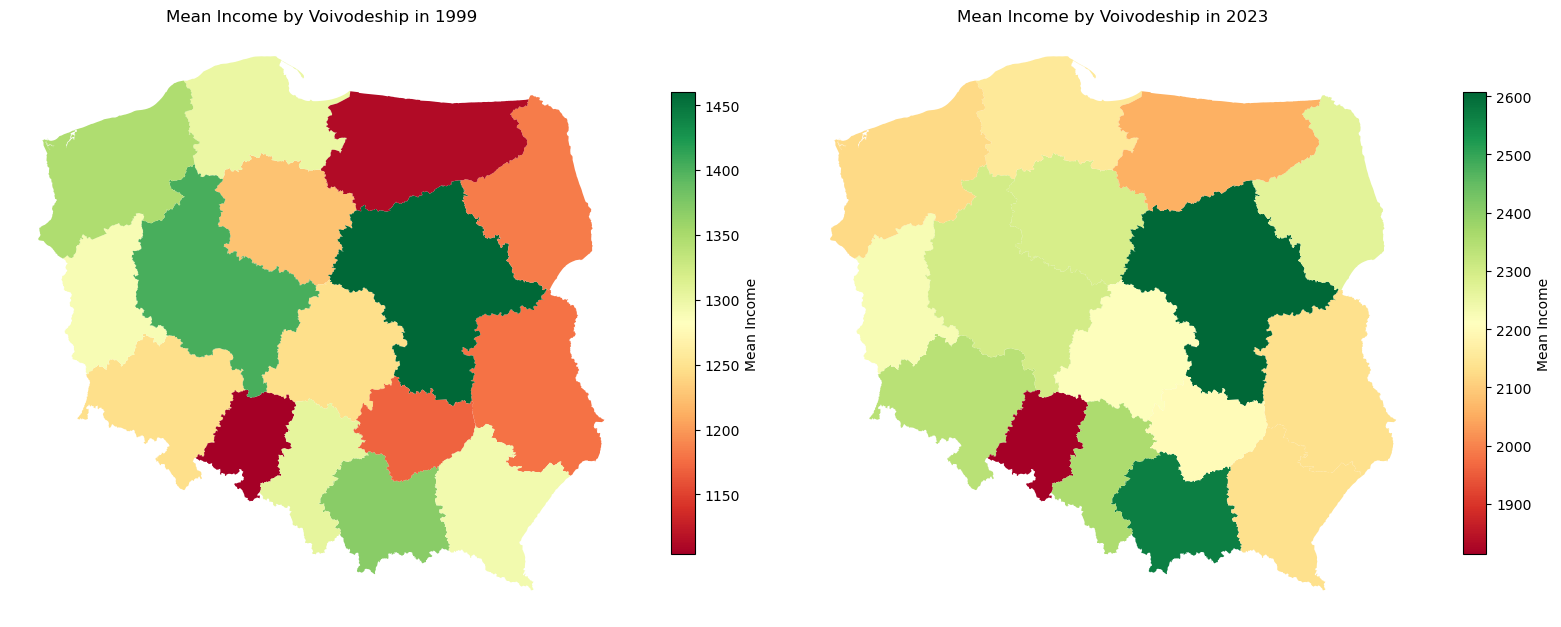

In [74]:
# Two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1999
gdf_means_1999.plot(column='mean_income', ax=ax1, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Income",
                                 'shrink': 0.6})
ax1.set_title("Mean Income by Voivodeship in 1999")
ax1.axis("off")
# Plot for 2016
gdf_means_2023.plot(column='mean_income', ax=ax2, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Income",
                                 'shrink': 0.6})
ax2.set_title("Mean Income by Voivodeship in 2023")
ax2.axis("off")
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_06_1.png', dpi=300)
plt.show()

In [75]:
regions = list(voivodeship_dataframes.keys())
gdf_top1_1999 = gdf.copy()
for region in regions:
    means = voivodeship_dataframes[region]['hinoncap_Top_10']
    mean = means[means.index.year == 1999].values[0]
    gdf_top1_1999.loc[gdf_top1_1999['NAME_1'] == region, 'hinoncap_Top_10'] = mean

gdf_top1_2023 = gdf.copy()
for region in regions:
    means = voivodeship_dataframes[region]['hinoncap_Top_10']
    mean = means[means.index.year == 2023].values[0]
    gdf_top1_2023.loc[gdf_top1_2023['NAME_1'] == region, 'hinoncap_Top_10'] = mean
    

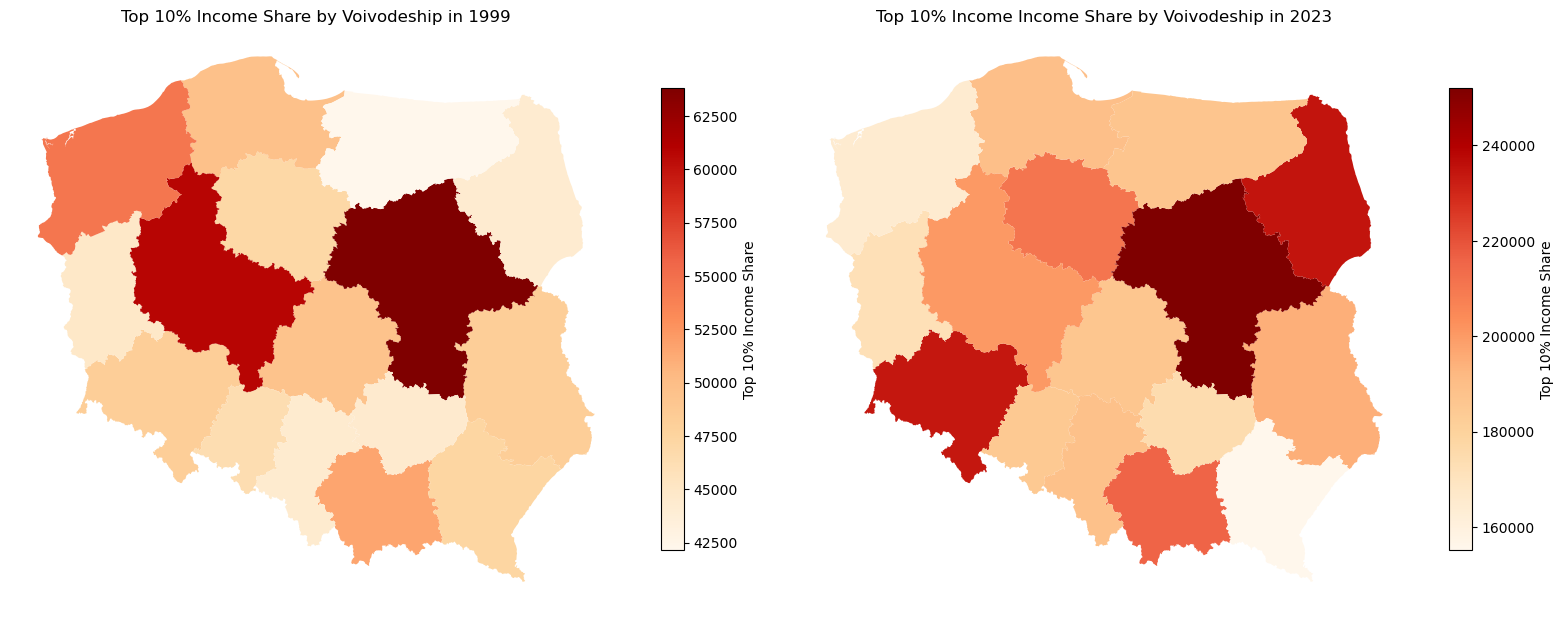

In [76]:
# Two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1999
gdf_top1_1999.plot(column='hinoncap_Top_10', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 1999")
ax1.axis("off")
# Plot for 2016
gdf_top1_2023.plot(column='hinoncap_Top_10', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Income Share by Voivodeship in 2023")
ax2.axis("off")
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_06_2.png', dpi=300)
plt.show()